# 1. Data preparation

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import prepare_modeling_data

modeling_catalog, split_summary = prepare_modeling_data()

display(split_summary)

D:\AST\05_JADES_PhotoZ_ML\src\data.py:209: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  catalog[SOURCE_KEY_COLUMN] = _build_source_key(catalog)


,split,sources,fraction,median_z_spec,minimum_z_spec,maximum_z_spec,hybrid_sources
0,train,2219,0.699779,2.940861,0.142322,14.179600,2219
1,validation,476,0.150110,2.934933,0.243921,10.407481,476
2,test,476,0.150110,2.969288,0.253300,13.860000,476


# 2. Training-only resampling

In [2]:
from src.resampling import prepare_resampling_data

(
    weighted_training_catalog,
    augmented_training_catalog,
    resampling_summary,
) = prepare_resampling_data()

display(resampling_summary)

,redshift_stratum,minimum_z_spec,maximum_z_spec,original_sources,source_weight,synthetic_rows,total_training_rows
0,0,0.142322,0.991044,101,3.138614,202,303
1,1,1.001000,1.999879,456,0.695175,0,456
2,2,2.000000,2.999001,616,0.514610,0,616
3,3,3.000775,3.980397,447,0.709172,0,447
4,4,4.016185,5.989092,412,0.769417,0,412
5,5,6.000005,7.963877,146,2.171233,292,438
6,6,8.221385,14.179600,41,4.000000,82,123


# 3. Features

In [3]:
from src.features import prepare_feature_data

feature_catalogs, feature_summary = (
    prepare_feature_data()
)

display(feature_summary)

,catalog,rows,physical_sources,augmented_rows,full_feature_columns,median_finite_features,finite_eazy_fraction
0,weighted_train,2219,2219,0,57,57.0,1.0
1,augmented_train,2795,2219,576,57,57.0,1.0
2,validation,476,476,0,57,57.0,1.0
3,test,476,476,0,57,57.0,1.0


In [4]:
%pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.


In [6]:
import sys
import xgboost

print("Python:", sys.executable)
print("XGBoost:", xgboost.__version__)

Python: D:\Anaconda_envs\jwst\python.exe
XGBoost: 3.2.0


# 4. XGBoost

In [7]:
from src.xgboost import run_validation_experiments

(
    validation_metrics,
    validation_predictions,
) = run_validation_experiments()

display(validation_metrics)

,validation_rank,sources_with_finite_prediction_and_z_spec,normalized_bias,normalized_median_absolute_error,sigma_nmad,mean_absolute_redshift_error,catastrophic_outlier_threshold,catastrophic_outliers,catastrophic_outlier_fraction,experiment_id,method,training_rows,training_physical_sources,features,uses_sample_weights,uses_augmentation,uses_eazy,trees_used,early_stopping_score
0,1,476,0.012392,0.022105,0.027172,0.212583,0.15,20,0.042017,eazy_dr5_za,EAZY DR5 z_a,0,0,0,False,False,True,0,NaN
1,2,476,0.002017,0.025400,0.038534,0.203281,0.15,25,0.052521,xgb_eazy_hybrid,XGBoost: EAZY hybrid,2219,2219,58,True,False,True,1553,0.050663
2,3,476,0.004897,0.066669,0.099464,0.465449,0.15,106,0.222689,xgb_full_weighted,XGBoost: full + weights,2219,2219,57,True,False,False,5000,0.109490
3,4,476,0.004964,0.067242,0.098070,0.455738,0.15,107,0.224790,xgb_full_unweighted,XGBoost: full features,2219,2219,57,False,False,False,1811,0.107962
4,5,476,0.008615,0.075513,0.109745,0.482476,0.15,111,0.233193,xgb_full_augmented,XGBoost: full + weights + augmentation,2795,2219,57,True,True,False,3675,0.113559
5,6,476,-0.009178,0.100103,0.147082,0.680341,0.15,178,0.373950,xgb_raw_unweighted,XGBoost: raw photometry,2219,2219,28,False,False,False,2584,0.165462


# 5. Gated residual hybrid

In [8]:
from src.hybrid import run_gated_residual_hybrid

(
    hybrid_validation_metrics,
    hybrid_validation_predictions,
) = run_gated_residual_hybrid()

display(hybrid_validation_metrics)

,validation_rank,sources_with_finite_prediction_and_z_spec,normalized_bias,normalized_median_absolute_error,sigma_nmad,mean_absolute_redshift_error,catastrophic_outlier_threshold,catastrophic_outliers,catastrophic_outlier_fraction,experiment_id,method,correction_fraction,gate_threshold
0,1,476,0.003498,0.016529,0.024317,0.177573,0.15,19,0.039916,xgb_eazy_gated_residual,XGBoost: gated residual hybrid,0.542017,0.5
1,2,476,0.012392,0.022105,0.027172,0.212583,0.15,20,0.042017,eazy_dr5_za,EAZY DR5 z_a,0.000000,NaN
2,3,476,0.001693,0.020198,0.029495,0.194383,0.15,25,0.052521,xgb_eazy_residual_hybrid,XGBoost: EAZY residual hybrid,1.000000,0.0
3,4,476,0.002017,0.025400,0.038534,0.203281,0.15,25,0.052521,xgb_eazy_direct_hybrid,XGBoost: direct EAZY hybrid,1.000000,NaN


# 6. Test

,sources_with_finite_prediction_and_z_spec,normalized_bias,normalized_median_absolute_error,sigma_nmad,mean_absolute_redshift_error,catastrophic_outlier_threshold,catastrophic_outliers,catastrophic_outlier_fraction,experiment_id,method,pre_test_role,correction_fraction
0,476,0.010433,0.017061,0.021029,0.170490,0.15,20,0.042017,eazy_dr5_za,EAZY DR5 z_a,Published template-fitting benchmark,NaN
1,476,-0.002838,0.058638,0.087048,0.421305,0.15,97,0.203782,xgb_full_weighted,XGBoost: full + weights,Best pure-ML validation configuration,NaN
2,476,-0.000148,0.028735,0.042595,0.185811,0.15,31,0.065126,xgb_eazy_direct_hybrid,XGBoost: direct EAZY hybrid,Direct-hybrid ablation,NaN
3,476,0.003361,0.014293,0.022499,0.135674,0.15,16,0.033613,xgb_eazy_gated_residual,XGBoost: gated residual hybrid,Selected before opening test,0.533613


,method,redshift_stratum,z_spec_bin,sources,median_z_spec,sources_with_finite_prediction_and_z_spec,normalized_bias,normalized_median_absolute_error,sigma_nmad,mean_absolute_redshift_error,catastrophic_outlier_threshold,catastrophic_outliers,catastrophic_outlier_fraction
0,EAZY DR5 z_a,0,0 <= z < 1,22,0.745770,22,-0.012233,0.015091,0.032149,0.055706,0.15,0,0.000000
1,EAZY DR5 z_a,1,1 <= z < 2,98,1.642728,98,0.008856,0.021241,0.025739,0.137845,0.15,6,0.061224
2,EAZY DR5 z_a,2,2 <= z < 3,132,2.573042,132,0.012911,0.018496,0.024327,0.183759,0.15,7,0.053030
3,EAZY DR5 z_a,3,3 <= z < 4,96,3.479025,96,0.010618,0.018785,0.023509,0.274711,0.15,7,0.072917
4,EAZY DR5 z_a,4,4 <= z < 6,88,4.935246,88,0.010650,0.012193,0.013966,0.111355,0.15,0,0.000000
5,EAZY DR5 z_a,5,6 <= z < 8,31,6.757951,31,0.003589,0.012978,0.013919,0.115659,0.15,0,0.000000
6,EAZY DR5 z_a,6,z >= 8,9,8.815875,9,0.020154,0.020154,0.028584,0.267302,0.15,0,0.000000
7,XGBoost: gated residual hybrid,0,0 <= z < 1,22,0.745770,22,0.003162,0.016700,0.025295,0.050961,0.15,0,0.000000
8,XGBoost: gated residual hybrid,1,1 <= z < 2,98,1.642728,98,0.008526,0.021103,0.024689,0.126534,0.15,5,0.051020
9,XGBoost: gated residual hybrid,2,2 <= z < 3,132,2.573042,132,0.003245,0.016599,0.023404,0.115769,0.15,4,0.030303


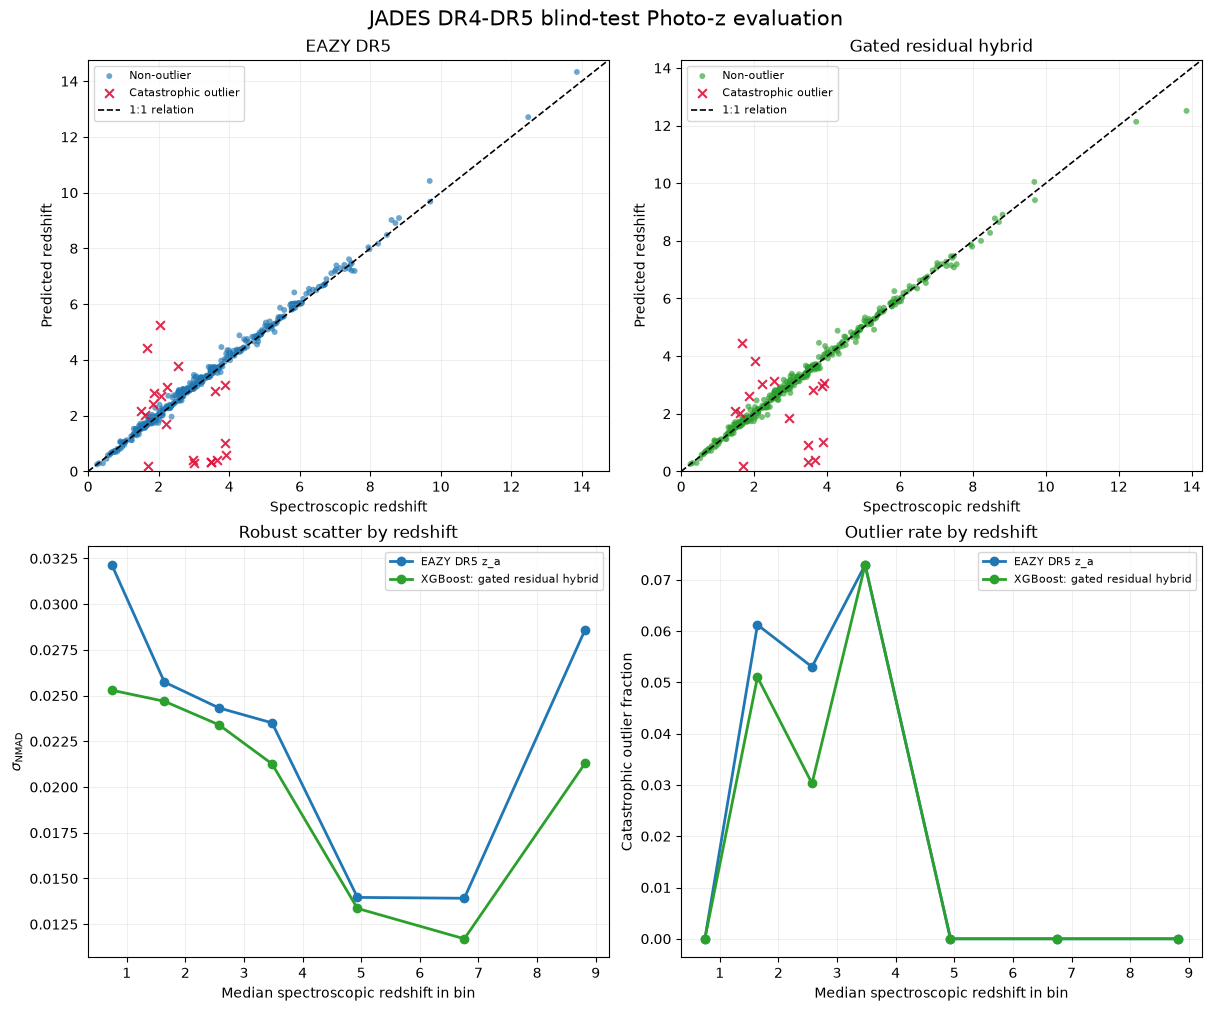

In [12]:
from src.test import run_final_test_evaluation

(
    final_test_metrics,
    final_redshift_metrics,
    final_test_predictions,
    final_test_figure,
) = run_final_test_evaluation()

display(final_test_metrics)
display(final_redshift_metrics)

## Final results

| Metric | EAZY | Gated residual hybrid | Change |
|---|---:|---:|---:|
| Normalized bias | 0.01043 | **0.00336** | Absolute bias reduced by **67.8%** |
| Median absolute normalized error | 0.01706 | **0.01429** | Reduced by **16.2%** |
| $\sigma_{\mathrm{NMAD}}$ | **0.02103** | 0.02250 | Increased by **7.0%** |
| Mean absolute redshift error | 0.17049 | **0.13567** | Reduced by **20.4%** |
| Catastrophic outliers | 20 | **16** | Reduced by **4 sources** |
| Catastrophic outlier fraction | 4.20% | **3.36%** | Relatively reduced by **20.0%** |


# 7. Paired uncertainty analysis

,metric,metric_label,eazy_point,hybrid_point,hybrid_minus_eazy,delta_ci_lower_95,delta_ci_upper_95,relative_improvement_percent,relative_improvement_ci_lower_95,relative_improvement_ci_upper_95,bootstrap_probability_hybrid_better
0,absolute_normalized_bias,Absolute normalized bias,0.010433,0.003361,-0.007072,-0.008464,-0.004490,67.784113,53.553224,80.947817,1.0000
1,normalized_median_absolute_error,Median absolute normalized error,0.017061,0.014293,-0.002768,-0.005075,-0.000145,16.222454,0.940390,26.403129,0.9817
2,sigma_nmad,Sigma NMAD,0.021029,0.022499,0.001470,-0.002731,0.003744,-6.989903,-19.127768,12.320447,0.3169
3,mean_absolute_redshift_error,Mean absolute redshift error,0.170490,0.135674,-0.034816,-0.054578,-0.018056,20.421361,11.867352,28.996762,1.0000
4,catastrophic_outlier_fraction,Catastrophic outlier fraction,0.042017,0.033613,-0.008403,-0.016807,-0.002101,20.000000,4.545455,39.130435,0.9841


,sources,both_non_outliers,eazy_outlier_hybrid_non_outlier,eazy_non_outlier_hybrid_outlier,both_outliers,discordant_pairs,fixed_to_introduced_ratio,exact_mcnemar_p_value
0,476,456,4,0,16,4,inf,0.125


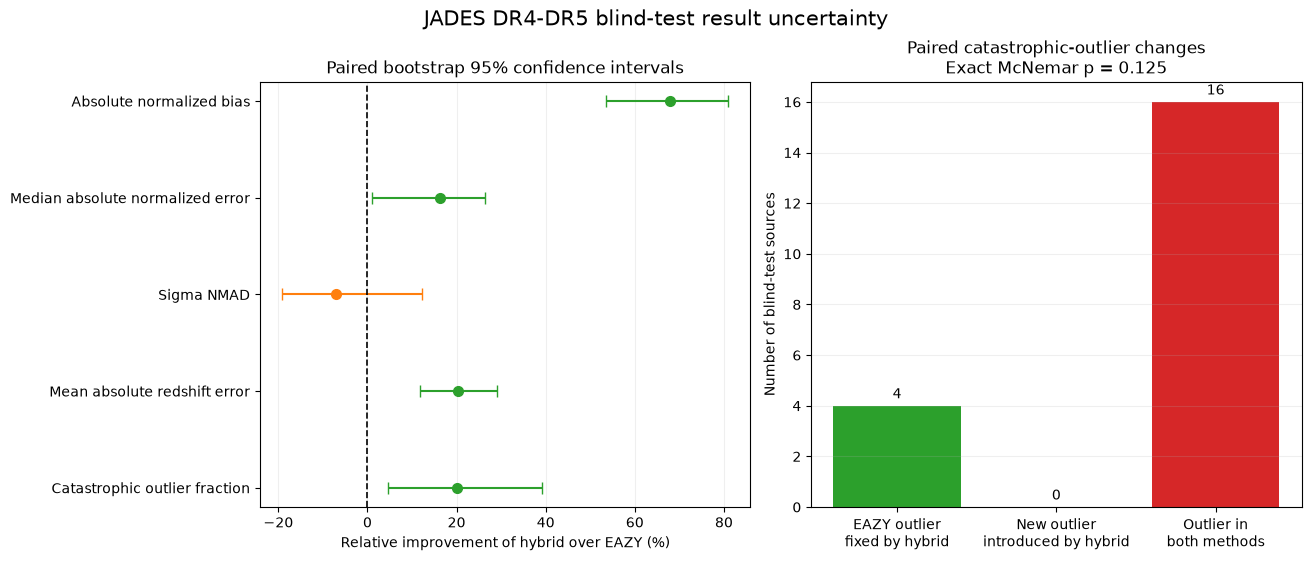

In [13]:
from src.uncertainty import (
    run_uncertainty_analysis,
)

(
    bootstrap_summary,
    outlier_comparison,
    uncertainty_figure,
) = run_uncertainty_analysis()

display(bootstrap_summary)
display(outlier_comparison)
display(uncertainty_figure)

# 8. TreeSHAP model interpretation

,model,output_unit,rank,feature,feature_label,mean_absolute_shap,mean_signed_shap,missing_fraction
0,Residual regressor,log-redshift residual,1,x_eazy_z_a,EAZY z_a,0.020425,-0.005023,0.000000
1,Residual regressor,log-redshift residual,2,x_eazy_delta_za_z500,EAZY z_a minus z500,0.015251,0.000896,0.000000
2,Residual regressor,log-redshift residual,3,x_eazy_normalized_interval_width,Normalized EAZY interval width,0.007366,0.001894,0.000000
3,Residual regressor,log-redshift residual,4,x_eazy_log_chi,log(1 + EAZY chi-square),0.005191,0.003077,0.000000
4,Residual regressor,log-redshift residual,5,x_flux_f090w_njy,Flux F090W,0.005190,0.001455,0.002101
5,Residual regressor,log-redshift residual,6,x_eazy_log1p_za,log(1 + EAZY z_a),0.003142,-0.000801,0.000000
6,Residual regressor,log-redshift residual,7,x_eazy_interval_width,EAZY 68% interval width,0.002948,-0.000067,0.000000
7,Residual regressor,log-redshift residual,8,x_color_f200w_f277w,Color F200W - F277W,0.002503,-0.000194,0.029412
8,Residual regressor,log-redshift residual,9,x_log_snr_f090w,log S/N F090W,0.002500,0.001203,0.002101
9,Residual regressor,log-redshift residual,10,x_fluxerr_f356w_njy,Flux uncertainty F356W,0.002453,-0.001102,0.000000


,selected_case_group,source_key,z_spec,z_eazy,z_hybrid,eazy_absolute_normalized_error,hybrid_absolute_normalized_error,normalized_error_improvement,correction_applied,gate_probability
0,Fixed catastrophic outlier,GN:1001625,2.992574,0.29,2.720474,0.676900,0.068151,0.608749,True,0.677186
1,Fixed catastrophic outlier,GS:431094,2.066960,2.69,2.460239,0.203146,0.128231,0.074915,True,0.764211
2,Fixed catastrophic outlier,GS:285054,1.843151,2.42,2.249475,0.202890,0.142913,0.059977,True,0.891263
3,Fixed catastrophic outlier,GS:216706,2.216476,1.71,1.883077,0.157463,0.103653,0.053810,True,0.650756
4,Shared catastrophic outlier,GS:184342,2.034060,5.26,3.834229,1.063242,0.593320,0.469922,True,0.585363
5,Shared catastrophic outlier,GN:1068536,1.674456,4.44,4.440000,1.034058,1.034058,0.000000,False,0.449519
6,Largest non-catastrophic improvement,GN:1016389,2.270799,2.71,2.482790,0.134279,0.064813,0.069466,True,0.655501
7,Largest non-catastrophic improvement,GS:141088,2.025144,2.39,2.231115,0.120608,0.068086,0.052521,True,0.608493
8,Largest non-catastrophic harm,GS:413345,2.811300,2.90,3.179777,0.023273,0.096680,-0.073407,True,0.739729
9,Largest non-catastrophic harm,GS:18044,13.860000,14.33,12.509657,0.031629,0.090871,-0.059242,True,0.539745


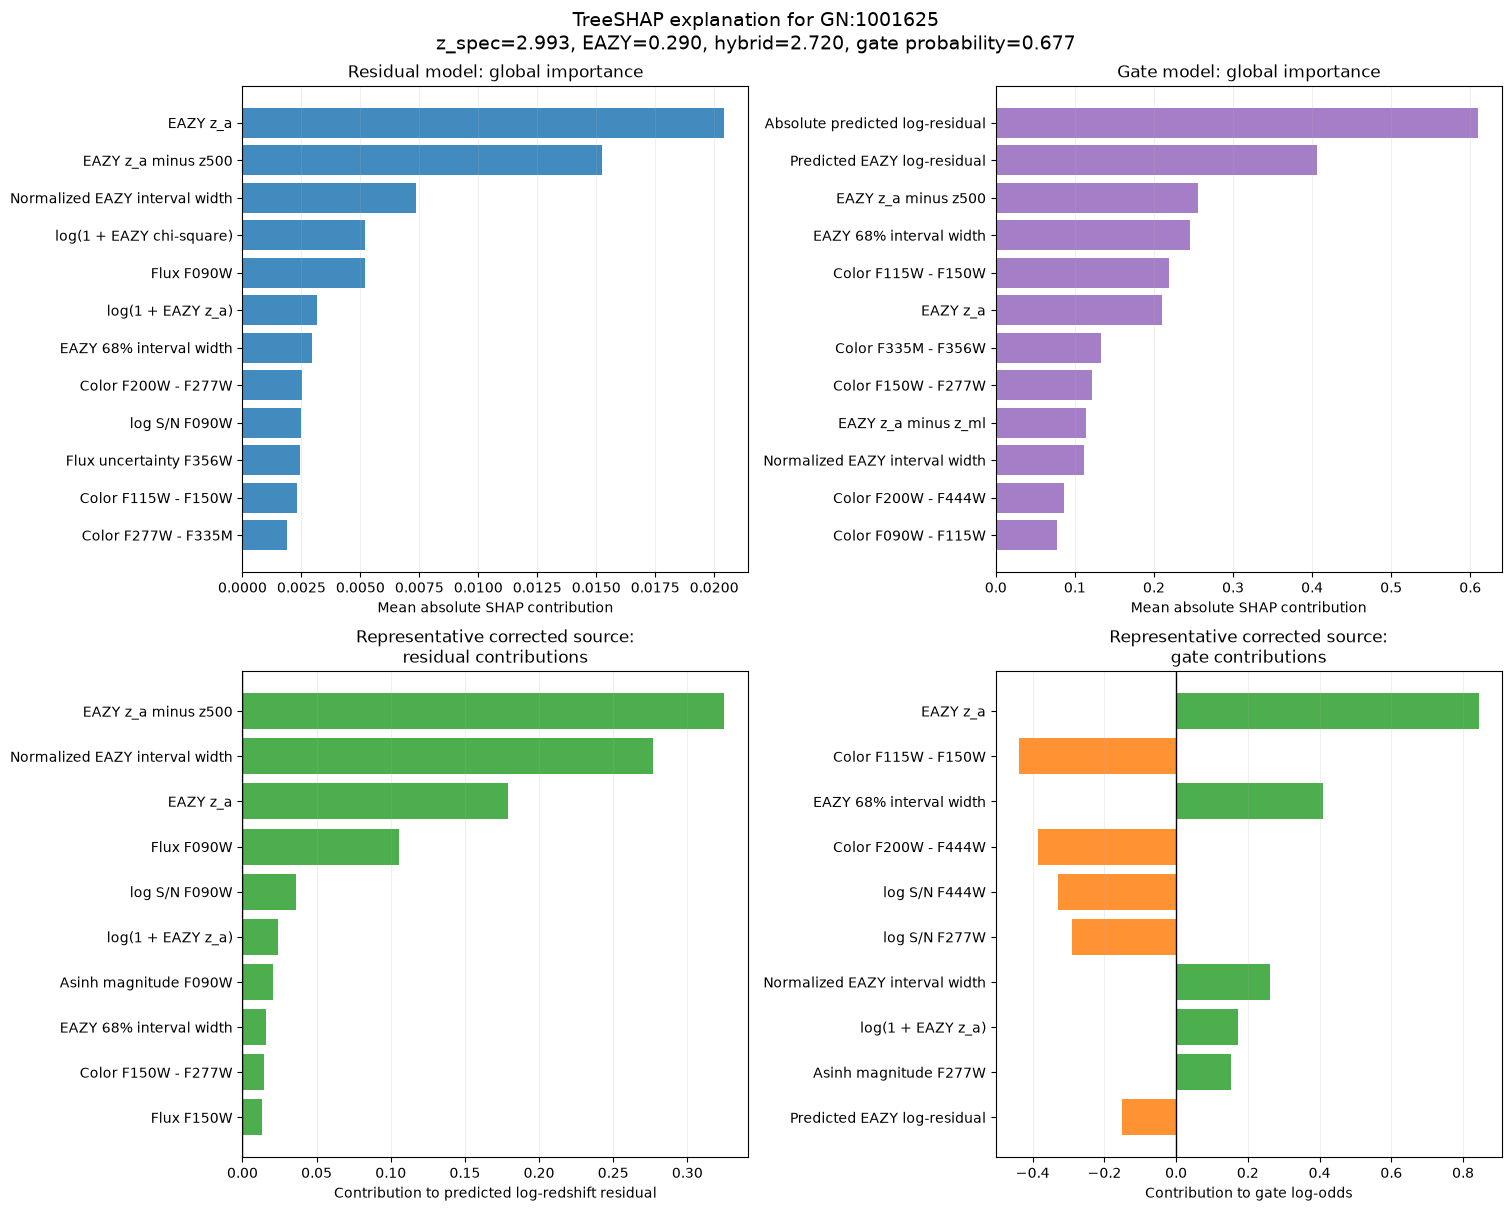

In [15]:
import importlib
import src.explain as explain_module

importlib.reload(explain_module)

(
    global_shap_importance,
    explanation_cases,
    explanation_figure,
) = explain_module.run_tree_shap_explanations()

top_shap_features = (
    global_shap_importance
    .groupby("model", sort=False)
    .head(10)
)

display(top_shap_features)
display(explanation_cases)
display(explanation_figure)